# Early Detection of the Heart Disease
Understanding the Business Problem

Heart diseases remain one of the leading cause of mortality worldwide.Hospital network(Inc),has developed a predictive machine learning pipeline that early-on, accurately identifies patients at risk,optimizes resources allocation, and  enables timely interventions, thus improving patient care while reducing the financial burden on the healthcare system.

Our dataset has been retrieved from Kaggel and stored on my github account(Phiona Namugga).It includes features like Gender, Age, BloodPressure, HeartRate,Cholesterol,  and HeartDisease condition  indicating the presence (1) or absence (0) of heart disease.

To accomplish this, the pipeline leverages a stacking ensemble approach, combining diverse base models i.e; XGBoost, Random Forest, Support Vector Machine (SVM), and Logistic Regression to capture a wide range of patterns in the data. The pipeline incorporates comprehensive preprocessing, feature engineering, hyperparameter tuning, and rigorous model validation to maximize predictive performance. Preprocessing steps like feature scaling and polynomial feature creation ensure the data is optimally prepared, while validation techniques such as k-fold cross-validation, learning curves, and detailed classification metrics (e.g., confusion matrix, precision-recall curve) confirm the model’s robustness and reliability. Additionally, the pipeline addresses challenges like the jaggedness of the precision-recall curve by calibrating probability outputs and using cross-validated predictions, ensuring both high performance and clear interpretability. Ultimately, this pipeline is designed to deliver a highly accurate and awell-validated solution for heart disease prediction.


## 1. Import libraries

In [38]:
import pandas as pd
import numpy as np
from pandas import DataFrame
from sklearn.model_selection import train_test_split, cross_val_score,learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


## 2. Data Exploration and Preprocessing

In [50]:
# Loads the dataset was retrieved from Kaggle and stored on my github account.Using the provided URL and converts it into a structured format (e.g., pandas DataFrame) for easy manipulation
url = "https://raw.githubusercontent.com/Phionanamugga/Early_Detection_of_Heart_Disease-/refs/heads/feature1/heart_disease_dataset_with_nan.csv"
df = pd.read_csv(url)

# Displaying the headings of the dataset
print(df.head())

    Age  Gender  BloodPressure  Cholesterol  HeartRate  QuantumPatternFeature  \
0  68.0     NaN          105.0          NaN        NaN               8.362241   
1  58.0     NaN           97.0        249.0       89.0                    NaN   
2  44.0     0.0           93.0        190.0        NaN               7.942542   
3  72.0     1.0           93.0        183.0      101.0               6.495155   
4  37.0     0.0          145.0          NaN        NaN               7.653900   

   HeartDisease  
0           1.0  
1           NaN  
2           1.0  
3           1.0  
4           1.0  


In [78]:
# checking the number of rows and columns in the dataset
df.shape

(500, 7)

In [77]:
# Checking to find if dataset has missing values
print(df.isna().sum().sum())

371


In [58]:
# fills missing values
data_org = df.copy(deep=True)
data_org['Age'] = data_org['Age'].fillna(data_org['Age'].mode())
data_org['Gender'] = data_org['Gender'].fillna(data_org['Gender'].mode())
data_org['BloodPressure'] = data_org['BloodPressure'].fillna(data_org['BloodPressure'].mean())
data_org['Cholesterol'] = data_org['Cholesterol'].fillna(data_org['Cholesterol'].mode())
data_org['HeartRate'] = data_org['HeartRate'].fillna(data_org['HeartRate'].mean())
data_org['QuantumPatternFeature'] = data_org['QuantumPatternFeature'].fillna(data_org['QuantumPatternFeature'].mean())
data_org['HeartDisease'] = data_org['HeartDisease'].fillna(1)

In [69]:
data_org.to_csv('heart_disease_dataset_imputed.csv', index=False)

In [74]:
df_impt = pd.read_csv('https://raw.githubusercontent.com/Phionanamugga/Early_Detection_of_Heart_Disease-/refs/heads/feature1/heart_disease_dataset_imputed.csv')


In [81]:
print(df_impt.isna().sum().sum())

371


In [66]:
# Displaying distributions after imputation
print(data_org['Age'].value_counts().sum())
print(data_org['Gender'].value_counts().sum())
print(data_org['BloodPressure'].value_counts().sum())
print(data_org['Cholesterol'].value_counts().sum())
print(data_org['HeartRate'].value_counts().sum())
print(data_org['QuantumPatternFeature'].value_counts().sum())
print(data_org['HeartDisease'].value_counts().sum())


385
367
500
377
500
500
500


In [67]:
print(df.isna().sum().sum())

883


In [68]:
df.shape

(500, 7)

In [ ]:
# Dropping the null values(cleaning the dataset)
data_org = df.copy(deep=True)
data_org.dropna(inplace=True)
# Filling missing values
data_org['Timestamp'] = data_org['Timestamp'].fillna(data_org['Timestamp'].mode()[0])  # Using most frequent timestamp
data_org['Latitude'] = data_org['Latitude'].fillna(data_org['Latitude'].mean()) # Latitude (numeric, float) - filling the null values with the mean value of the latitudes
data_org['Longitude'] = data_org['Longitude'].fillna(data_org['Longitude'].mean()) # Longitude (numeric, float) - filling the null values with the mean value of the longitudes
data_org['Vehicle_Count'] = data_org['Vehicle_Count'].fillna(data_org['Vehicle_Count'].median()) # Vehicle_Count (numeric, integer) - filling the null values with median of the vehicle count since its robust to outliers
data_org['Traffic_Speed_kmh'] = data_org['Traffic_Speed_kmh'].fillna(data_org['Traffic_Speed_kmh'].mean()) # Traffic_Speed_kmh (numeric, float) - fills the null values with the mean of the Traffic_Speed data
data_org['Road_Occupancy_%'] = data_org['Road_Occupancy_%'].fillna(data_org['Road_Occupancy_%'].mean()) # Road_Occupancy_% (numeric, float, percentage) - fills the null values with the mean of the Road_Occupancy data
data_org['Traffic_Light_State'] = data_org['Traffic_Light_State'].fillna(data_org['Traffic_Light_State'].mode()[0])# Traffic_Light_State (categorical) - fills the null vlaues with the mode (most frequent value) of Traffic_Light_State  data
data_org['Weather_Condition'] = data_org['Weather_Condition'].fillna(data_org['Weather_Condition'].mode()[0]) # Weather_Condition (categorical) - fills the null values with mode of Weather_Condition data
data_org['Accident_Report'] = data_org['Accident_Report'].fillna(data_org['Accident_Report'].mode()[0]) # Accident_Report (categorical  or likely boolean) - fills the null vlaues with the mode of Accident_Report data
data_org['Sentiment_Score'] = data_org['Sentiment_Score'].fillna(data_org['Sentiment_Score'].mean()) # Sentiment_Score (numeric, float) - fills the null values with the mean of the Sentiment_Score data
data_org['Ride_Sharing_Demand'] = data_org['Ride_Sharing_Demand'].fillna(data_org['Ride_Sharing_Demand'].median()) # Ride_Sharing_Demand (numeric, likely integer) - fills the null values with the median of Ride_Sharing_Demand data
data_org['Parking_Availability'] = data_org['Parking_Availability'].fillna(data_org['Parking_Availability'].mean()) # Parking_Availability (numeric or categorical) - assuming numeric, fills the null values with the mean of Parking_Availability data
data_org['Emission_Levels_g_km'] = data_org['Emission_Levels_g_km'].fillna(data_org['Emission_Levels_g_km'].mean()) # Emission_Levels_g_km (numeric, float) - fills the null values with the mean of the Emission_Levels data
data_org['Energy_Consumption_L_h'] = data_org['Energy_Consumption_L_h'].fillna(data_org['Energy_Consumption_L_h'].mean()) # Energy_Consumption_L_h (numeric, float) - fills the null values with the mean of the Energy_Consumption data
data_org['Traffic_Condition'] = data_org['Traffic_Condition'].fillna(data_org['Traffic_Condition'].mode()[0]) # Traffic_Condition (categorical) - fills the null values with mode of the Traffic_Condition data


print("Missing values after cleaning:") # Verifying that the data cleaning has been done
print(data_org.isna().sum())

# Checking basic statistics to ensure cleaning makes sense
print("\nBasic statistics after cleaning:")
print(data_org.describe())

In [ ]:
# Assuming df is already defined (e.g., loaded from the dataset)
# If not, load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Phionanamugga/Early_Detection_of_Heart_Disease-/refs/heads/feature1/Heart_Prediction_Quantum_Dataset.csv?token=GHSAT0AAAAAADANCVEQ3DDNLVOXACDWIUEKZ7ER2YA")

# Create a copy of the dataset
data = df.copy()

# Display the number of missing values before injecting NaN
print("Before injecting NaN:")
display(df.isna().sum())
print()

# Inject NaN values randomly
for _ in range(1000):  # Corrected syntax: space between _ and in
    i = np.random.randint(0, df.shape[0])  # Random row index
    j = np.random.randint(0, df.shape[1])  # Random column index
    df.iloc[i, j] = None  # Set the value to None (NaN in pandas)

# Display the number of missing values after injecting NaN
print('After injecting NaN:')
display(df.isna().sum())

# Save the modified dataset to a CSV file
df.to_csv('heart_disease_dataset_with_nan.csv', index=False)

Before injecting NaN:


,0
Age,0
Gender,0
BloodPressure,0
Cholesterol,0
HeartRate,0
QuantumPatternFeature,0
HeartDisease,0



After injecting NaN:


,0
Age,115
Gender,134
BloodPressure,133
Cholesterol,124
HeartRate,122
QuantumPatternFeature,127
HeartDisease,128


### 2.1 Data Exploration

In [ ]:
# Printing all column names in the dataset
print(df.columns)

Index(['Age', 'Gender', 'BloodPressure', 'Cholesterol', 'HeartRate',
       'QuantumPatternFeature', 'HeartDisease'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB
None


In [ ]:
print(df.iloc())

In [ ]:
#comparison operators and maskking
mask = df['Age'] > 50
print(mask)

0       True
1       True
2      False
3       True
4      False
       ...  
495    False
496    False
497    False
498     True
499     True
Name: Age, Length: 500, dtype: bool


Age                      0
Gender                   0
BloodPressure            0
Cholesterol              0
HeartRate                0
QuantumPatternFeature    0
HeartDisease             0
dtype: int64
HeartDisease
1    300
0    200
Name: count, dtype: int64


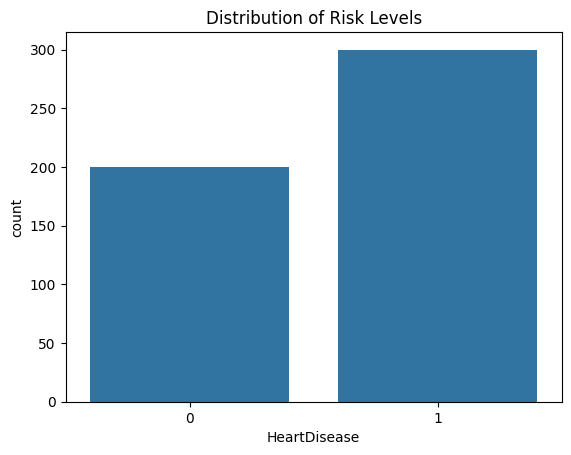

In [ ]:
# Checking for missing values
print(df.isnull().sum())

# Checking the distribution of the target variable
target_column = 'HeartDisease'
print(df[target_column].value_counts())

# Visualizing the target variable distribution
sns.countplot(x=target_column, data=df)
plt.title('Distribution of Risk Levels')
plt.show()

### 2.2 Data Preprocessing

In [ ]:
# checking for duplicated values
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
# checking if duplicated values still exist
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool


## 3.Feature engineering

In [ ]:
# Separating features (X) and target (y)
X = df.drop(columns=['HeartDisease'])  # Assuming 'HeartDisease' is the target column
y = df['HeartDisease']

In [ ]:
# Converting categorical variables to numerical (if any)
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Feature scaling and polynomial features
scaler = StandardScaler()
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

In [ ]:
# Check the class distribution in the training set
print(y_train.value_counts())

HeartDisease
1    240
0    160
Name: count, dtype: int64


In [ ]:
# Applying SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# Check the new class distribution after SMOTE
print(pd.Series(y_train_res).value_counts())

HeartDisease
1    240
0    240
Name: count, dtype: int64


## 4. Model Training

In [ ]:
# Training base models i.e Randon forest, Gradient Boosting (XGBoost), Support Vector Machine (SVM) and Logistic Regression to later be used for ensemble learning
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
xgb = XGBClassifier(learning_rate=0.1, n_estimators=100, max_depth=5, random_state=42)
svm = SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
lr = LogisticRegression(C=1.0, random_state=42)

In [ ]:
# Stacking ensemble
estimators = [('rf', rf), ('xgb', xgb), ('svm', svm), ('lr', lr)]
stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

In [ ]:
# Pipeline
pipeline = Pipeline([
    ('scaler', scaler),
    ('poly', poly),
    ('stacking', stacking_clf)
])

In [ ]:
# Fit the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('stacking',
                 StackingClassifier(estimators=[('rf',
                                                 RandomForestClassifier(max_depth=10,
                                                                        random_state=42)),
                                                ('xgb',
                                                 XGBClassifier(base_score=None,
                                                               booster=None,
                                                               callbacks=None,
                                                               colsample_bylevel=None,
                                                               colsample_bynode=None,
                                                               colsample_bytree=None,
                                                               d...
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=5,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=100,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               random_state=42, ...)),
                                                ('svm',
                                                 SVC(probability=True,
                                                     random_state=42)),
                                                ('lr',
                                                 LogisticRegression(random_state=42))],
                                    final_estimator=LogisticRegression()))])

## 5.Model Evaluation

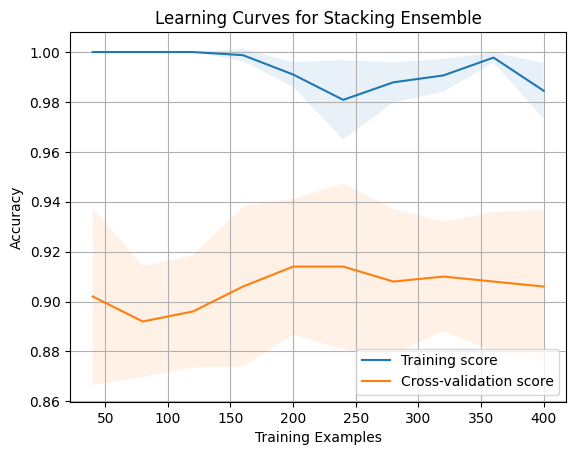

In [ ]:

# 2. Learning Curves
def plot_learning_curve(estimator, X, y, title="Learning Curves"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Training score")
    plt.plot(train_sizes, val_mean, label="Cross-validation score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Call the function
plot_learning_curve(pipeline, X, y, "Learning Curves for Stacking Ensemble")

Confusion Matrix:
[[34  6]
 [ 2 58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        40
           1       0.91      0.97      0.94        60

    accuracy                           0.92       100
   macro avg       0.93      0.91      0.92       100
weighted avg       0.92      0.92      0.92       100

ROC-AUC Score: 0.9829166666666667


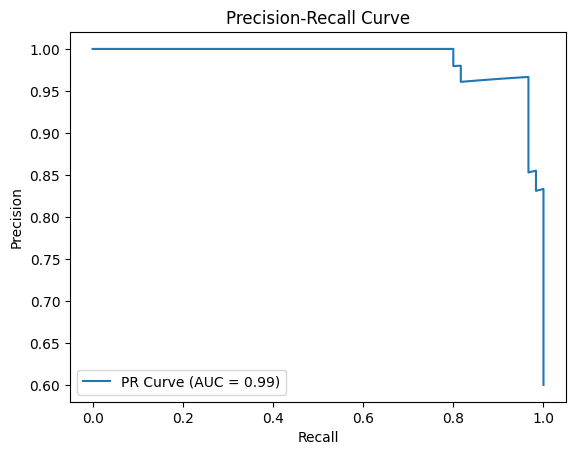

In [ ]:
# Predict on the test set
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc}")

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [ ]:
# Cross-validation score
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")

Mean CV Accuracy: 90.60%


## 6.Feature Importance

In [ ]:
# For Random Forest, visualize feature importance
if isinstance(pipeline, RandomForestClassifier):
    feature_importance = pipeline.feature_importances_
    feature_names = X.columns
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Feature Importance')
    plt.show()

## 7.Save the Model

In [ ]:


# Save the trained model
joblib.dump(pipeline, 'heart_disease_risk_model.pkl')

# Save the scaler
joblib.dump(pipeline, 'scaler.pkl')

['scaler.pkl']